# **Project Name -**

# DeepCSAT – Ecommerce Customer Satisfaction Score Prediction Through ANN Model

# **Project Summary -**

This project focuses on analyzing and predicting customer satisfaction (CSAT) in an eCommerce customer support environment using data analytics and machine learning techniques. The primary objective of this project is to understand the factors that influence customer satisfaction and build predictive models to estimate CSAT scores. The dataset includes multiple attributes such as communication channel, issue category, product category, handling time, agent details, and customer remarks.

The project begins with data preprocessing and data wrangling, where missing values, duplicate records, and inconsistent data formats are handled. Next, Exploratory Data Analysis (EDA) is performed to understand the distribution and relationships within the data. Various visualization techniques such as histograms, box plots, scatter plots, pie charts, correlation heatmaps, and pair plots are used to identify patterns, trends, and potential outliers.

Since the dataset contains textual customer feedback in the Customer Remarks column, Natural Language Processing (NLP) techniques are applied. After preprocessing, machine learning models are implemented to predict customer satisfaction. Both regression and classification approaches are explored. Models such as Linear Regression and Logistic Regression are trained using relevant features from the dataset. To ensure model reliability and prevent overfitting, cross-validation techniques are applied. Additionally, hyperparameter tuning using GridSearchCV is performed to optimize model performance and identify the best model configuration.

Finally, an Artificial Neural Network (ANN) model is developed using deep learning frameworks to capture complex relationships between features and customer satisfaction scores. The ANN architecture includes multiple dense layers with activation functions and optimization techniques to improve prediction accuracy.

# **GitHub Link -**

https://github.com/PODDA2N/AI-ML-Internship-of-DeepCSAT---Ecommerce-Customer-Satisfaction-Score

# **Problem Statement**

Customer satisfaction plays a critical role in customer retention, brand reputation, and overall business success. Customers frequently interact with support teams through different channels to resolve issues related to orders, products, and services. However, factors such as response time, agent handling efficiency, issue category, product type, and communication channel can significantly influence customer satisfaction levels.

The dataset contains detailed information about customer support interactions, including order details, issue reporting time, response time, product category, agent information, handling time, and customer feedback (remarks). Each interaction is associated with a Customer Satisfaction Score (CSAT Score), which reflects the customer's experience with the service provided.

The main challenge is to analyze and identify the key factors that influence customer satisfaction and develop predictive models to estimate CSAT scores based on operational and interaction-related variables.

By performing data preprocessing, exploratory data analysis (EDA), text analysis on customer remarks, and machine learning modeling, this project aims to:

Understand the relationship between customer support operations and satisfaction levels.

Identify factors that lead to higher or lower CSAT scores

Analyze customer feedback to extract meaningful insights

Build predictive models to forecast customer satisfaction based on historical interaction data

The insights derived from this analysis can help eCommerce organizations optimize customer support processes, improve agent performance, reduce issue resolution time, and enhance overall customer experience.


# ***Let's Begin !***

# ***1. Know Your Data***

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Dataset Loading

#### Dataset First View

In [3]:
data = pd.read_csv("E:\Data Analyst Coding\Machine Learning Project Internship\eCommerce_Customer_support_data.csv")
data

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30-08-2023 23:20,31-08-2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31-08-2023 08:15,31-08-2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31-08-2023 18:57,31-08-2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31-08-2023 19:59,31-08-2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4


#### Dataset Rows & Columns count

In [3]:
rows, columns = data.shape
rows, columns

(85907, 20)

#### Dataset Information

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [11]:
duplicate_values = data.duplicated(subset = ['Unique id','Order_id','Customer_City','Product_category','Item_price','CSAT Score']).sum()
duplicate_values

np.int64(0)

#### Missing Values/Null Values

In [3]:
data.isna()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,False,False,False,False,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
1,False,False,False,False,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
2,False,False,False,False,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
3,False,False,False,False,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
4,False,False,False,False,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,False,False,False,False,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
85903,False,False,False,False,False,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
85904,False,False,False,False,False,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False
85905,False,False,False,False,True,False,True,False,False,False,True,True,True,True,False,False,False,False,False,False


In [4]:
data.isna().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

#### What did you know about your dataset?

The dataset contains customer support interaction data from an eCommerce platform, including order details, issue reporting times, product information, agent handling data, and customer feedback. Each record represents a customer support case and includes a CSAT score that measures customer satisfaction. The dataset can be used to analyze factors influencing customer satisfaction and to build predictive models for CSAT.

# ***2. Understanding Your Variables***

In [7]:
data.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [8]:
data.describe()

,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


#### Variables Description

The dataset contains information related to customer support interactions in an eCommerce platform, including order details, issue reporting information, product details, agent performance data, and customer satisfaction feedback. The main target variable is CSAT Score, which represents the customer's satisfaction level after the issue resolution.

#### Check Unique Values for each variable.

In [12]:
for i in data.columns:
    print("Unique Values:", data[i].nunique())

Unique Values: 85907
Unique Values: 3
Unique Values: 12
Unique Values: 57
Unique Values: 18231
Unique Values: 67675
Unique Values: 13766
Unique Values: 30923
Unique Values: 30262
Unique Values: 31
Unique Values: 1782
Unique Values: 9
Unique Values: 2789
Unique Values: 211
Unique Values: 1371
Unique Values: 40
Unique Values: 6
Unique Values: 5
Unique Values: 5
Unique Values: 5


# ***3. Data Wrangling***

In [4]:
data['Customer Remarks'] = data['Customer Remarks'].fillna('')    # For text column Handle Missing Value
data['Customer Remarks']

0                                                
1                                                
2                                                
3                                                
4                                                
                           ...                   
85902                                            
85903    Supported team customer executive   good
85904        need to improve with proper details.
85905                                            
85906                                            
Name: Customer Remarks, Length: 85907, dtype: object

In [5]:
data['Item_price'] = data['Item_price'].fillna(data['Item_price'].median())         # For numerical columns Handle Missing Value
data['Item_price']

0        979.0
1        979.0
2        979.0
3        979.0
4        979.0
         ...  
85902    979.0
85903    979.0
85904    979.0
85905    979.0
85906    979.0
Name: Item_price, Length: 85907, dtype: float64

In [6]:
data['connected_handling_time'] = data['connected_handling_time'].fillna(data['connected_handling_time'].median())
data['connected_handling_time']

0        427.0
1        427.0
2        427.0
3        427.0
4        427.0
         ...  
85902    427.0
85903    427.0
85904    427.0
85905    427.0
85906    427.0
Name: connected_handling_time, Length: 85907, dtype: float64

In [7]:
data['channel_name'] = data['channel_name'].fillna(data['channel_name'].mode()[0])    # For categorical columns Hand;e Missing Value
data['channel_name']

0        Outcall
1        Outcall
2        Inbound
3        Inbound
4        Inbound
          ...   
85902    Inbound
85903    Inbound
85904    Inbound
85905    Inbound
85906    Inbound
Name: channel_name, Length: 85907, dtype: object

#### What all manipulations have you done and insights you found?

Data wrangling involved handling missing values, converting datetime fields, creating response-time features, and cleaning categorical and text data. EDA and visualization revealed relationships between handling time, issue categories, communication channels, and customer satisfaction. The analysis highlighted operational factors that significantly influence CSAT scores

# 4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

#### Heatmap Represents Check Missing Values

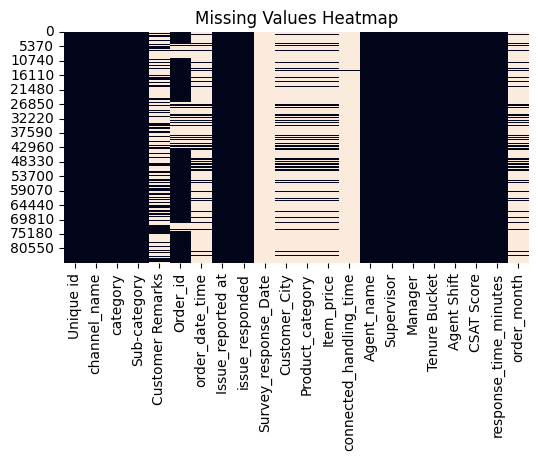

In [12]:
plt.figure(figsize=(6,3))
sns.heatmap(data.isnull(), cbar = False)
plt.title("Missing Values Heatmap")
plt.show()

#### Histogram Plot Represents Distribution of Item Price

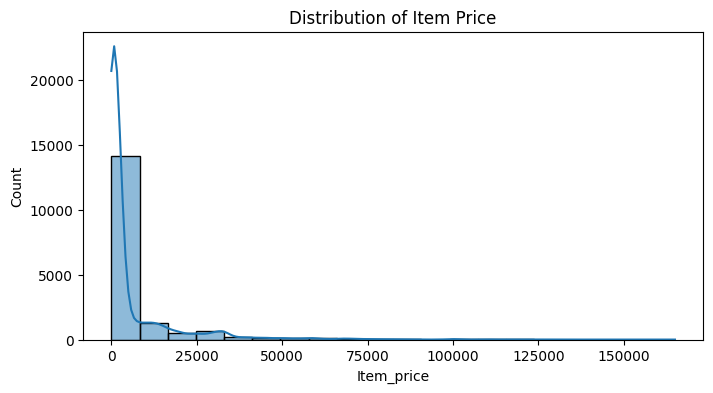

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(data["Item_price"], bins = 20, kde = True)
plt.title("Distribution of Item Price")
plt.show()

#### Histogram Plot Represents Handling Time Distribution

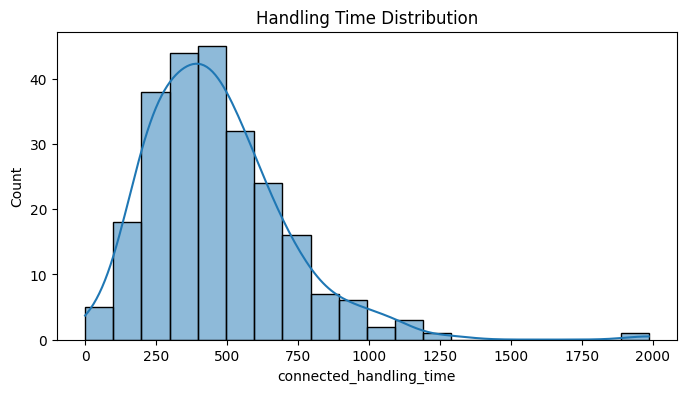

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(data["connected_handling_time"], bins = 20, kde = True)
plt.title("Handling Time Distribution")
plt.show()

#### Count Plot Represents CSAT Score Distribution

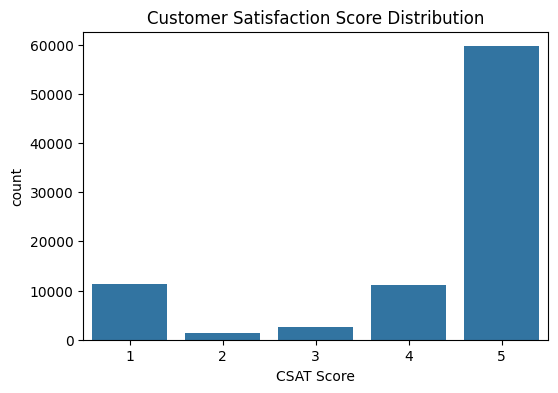

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(data = data, x = 'CSAT Score')
plt.title("Customer Satisfaction Score Distribution")
plt.show()

#### Box Plot Represents Item Price Outliers

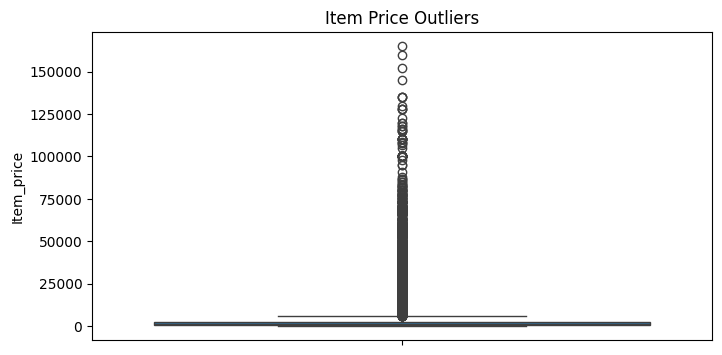

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(y = data['Item_price'])
plt.title("Item Price Outliers")
plt.show()

#### Box Plot Represents Connected Handling Time Outliers

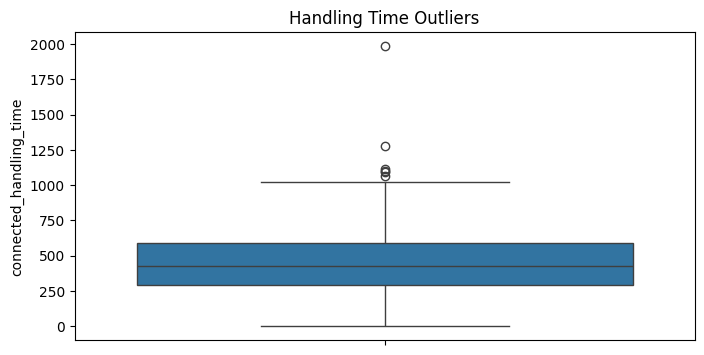

In [30]:
plt.figure(figsize=(8,4))
sns.boxplot(y = data['connected_handling_time'])
plt.title("Handling Time Outliers")
plt.show()

#### Box Plot Represents CSAT Score by Channel

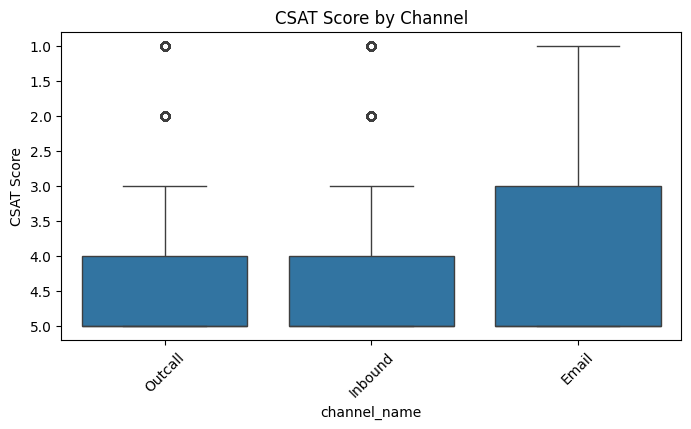

In [32]:
plt.figure(figsize=(8,4))
sns.boxplot(data=data, x = 'channel_name', y = 'CSAT Score')
plt.xticks(rotation = 45)
plt.title("CSAT Score by Channel")
plt.gca().invert_yaxis()
plt.show()

#### Top 10 Customer Cities 

In [41]:
top_cities = data["Customer_City"].value_counts().head(10)
top_cities

Customer_City
HYDERABAD    722
NEW DELHI    688
PUNE         435
MUMBAI       406
BANGALORE    352
CHENNAI      271
KOLKATA      270
LUCKNOW      254
AHMEDABAD    253
JAIPUR       243
Name: count, dtype: int64

#### Bar Plot Represents Top 10 Customer Cities

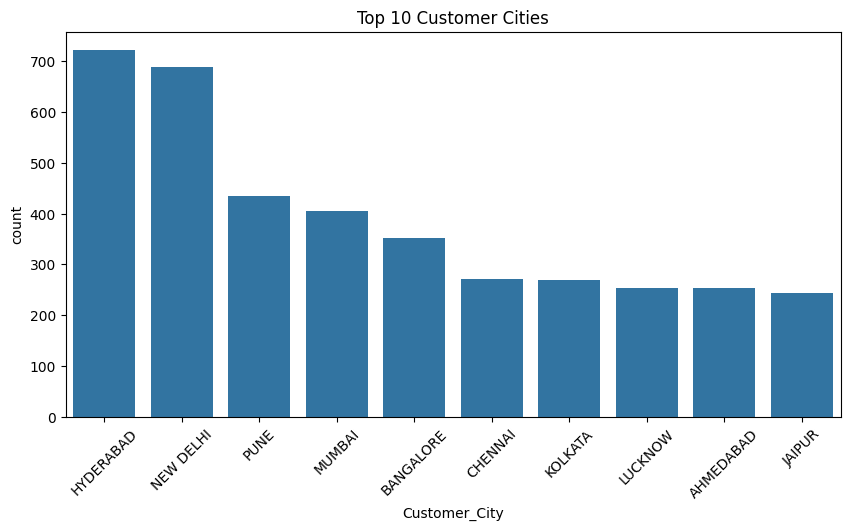

In [45]:
plt.figure(figsize = (10,5))
sns.barplot(data = top_cities)
plt.title("Top 10 Customer Cities")
plt.xticks(rotation = 45)
plt.show()

#### Box Plot Represents Agent Shift vs CSAT

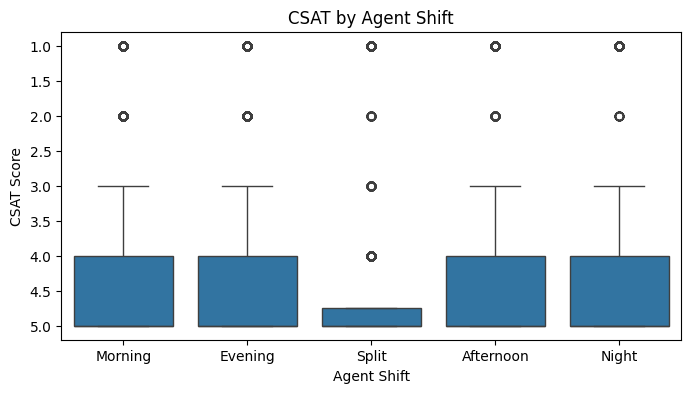

In [44]:
plt.figure (figsize = (8,4))
sns.boxplot(data = data, x = 'Agent Shift', y = 'CSAT Score')
plt.title("CSAT by Agent Shift")
plt.gca().invert_yaxis()
plt.show()

#### Count Plot Represents Product Category Distribution

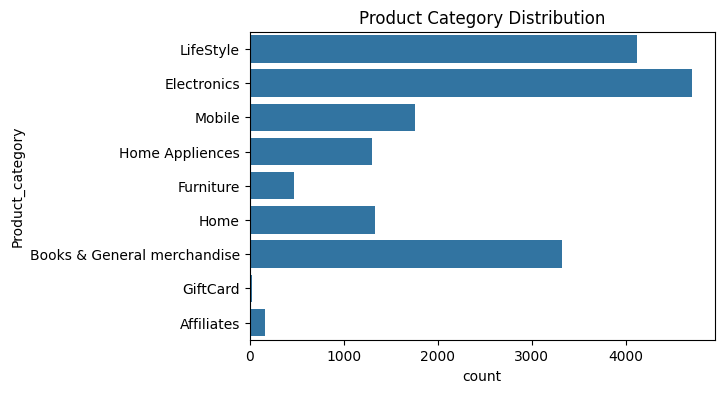

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(data = data, y = 'Product_category')
plt.title("Product Category Distribution")
plt.show()

#### Bar Plot Represents Lowest CSAT Supervisor Performance

In [53]:
supervisor_performance = data.groupby('Supervisor')['CSAT Score'].mean().sort_values().head(10)
supervisor_performance

Supervisor
Oliver Nguyen       3.503597
Sophia Chen         4.008902
Zoe Yamamoto        4.026471
Harper Wong         4.058088
Dylan Kim           4.070175
Emma Park           4.075988
Charlotte Suzuki    4.089590
Mia Yamamoto        4.089600
Austin Johnson      4.116077
Jacob Sato          4.161892
Name: CSAT Score, dtype: float64

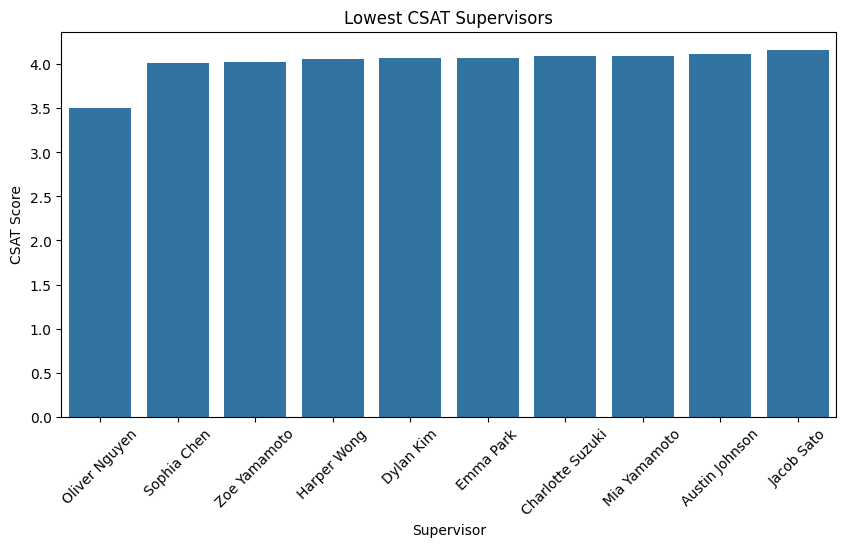

In [55]:
plt.figure(figsize = (10,5))
sns.barplot(data = supervisor_performance)
plt.title("Lowest CSAT Supervisors")
plt.xticks(rotation = 45)
plt.show()

#### Count Plot Represents Tenure Bucket Analysis

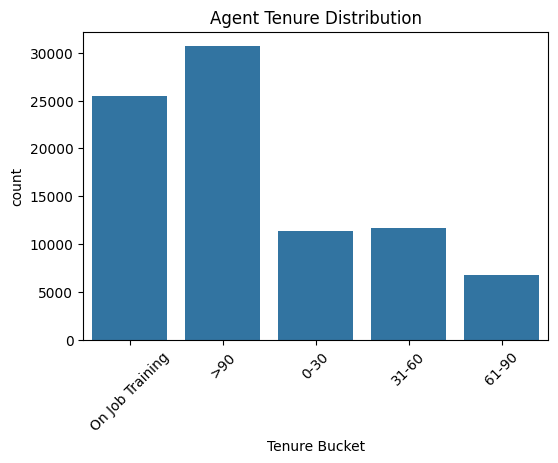

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(data = data, x='Tenure Bucket')
plt.xticks(rotation = 45)
plt.title("Agent Tenure Distribution")
plt.show()

#### Box Plot Represents Handling Time vs Category

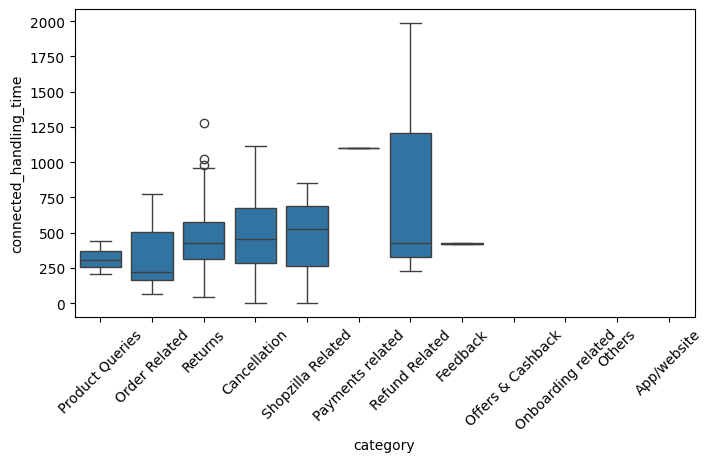

In [59]:
plt.figure(figsize=(8,4))
sns.boxplot(data = data, x = 'category', y = 'connected_handling_time')
plt.xticks(rotation=45)
plt.show()

#### Box Plot Represents CSAT Score vs Product Category

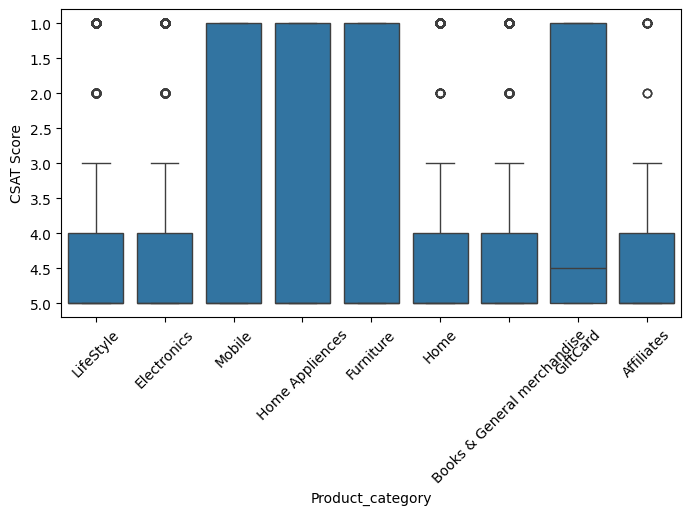

In [61]:
plt.figure(figsize=(8,4))
sns.boxplot(data = data, x = 'Product_category', y = 'CSAT Score')
plt.xticks(rotation = 45)
plt.gca().invert_yaxis()
plt.show()

#### Pie Plot Represents Customer Satisfaction Score Distribution

In [62]:
csat_counts = data['CSAT Score'].value_counts()
csat_counts

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64

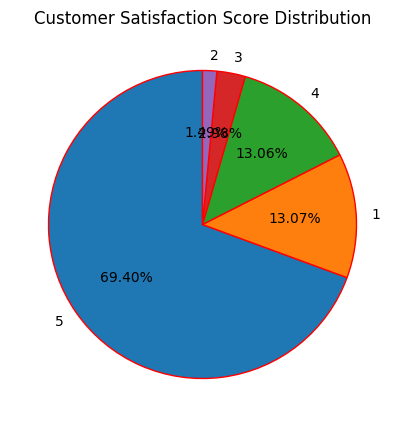

In [63]:
plt.figure(figsize=(5,5))
plt.pie(csat_counts,labels = csat_counts.index, autopct='%1.2f%%', startangle = 90, wedgeprops = {"edgecolor" : "Red"})
plt.title('Customer Satisfaction Score Distribution')
plt.show()

#### Pie Plot Represents Channel Name Distribution

In [64]:
channel_counts = data['channel_name'].value_counts()
channel_counts

channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64

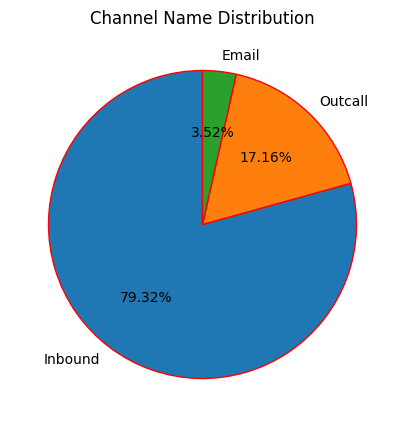

In [66]:
plt.figure(figsize=(5,5))
plt.pie(channel_counts,labels = channel_counts.index, autopct='%1.2f%%', startangle = 90, wedgeprops = {"edgecolor" : "Red"})
plt.title('Channel Name Distribution')
plt.show()

#### Scatter Plot Represents Handling Time vs CSAT

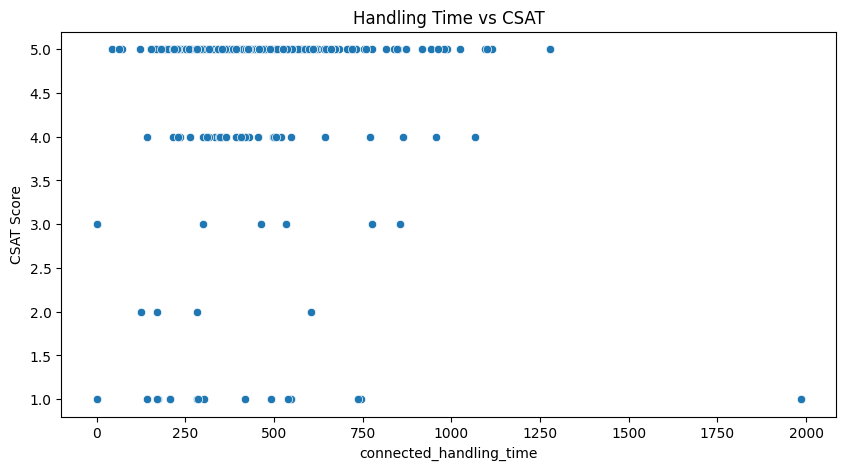

In [34]:
plt.figure (figsize = (10,5))
sns.scatterplot(data = data, x ='connected_handling_time', y ='CSAT Score')
plt.title("Handling Time vs CSAT")
plt.show()

#### Scatter Plot Represents Item Price vs CSAT

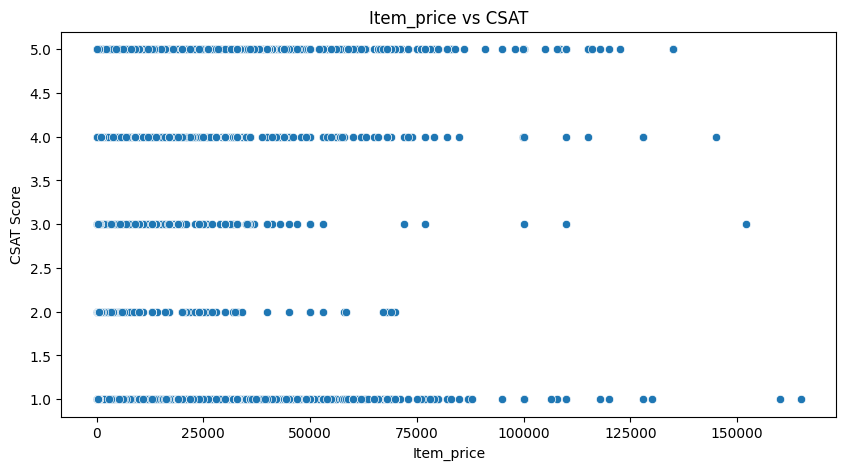

In [35]:
plt.figure (figsize = (10,5))
sns.scatterplot(data = data, x ='Item_price', y ='CSAT Score')
plt.title("Item_price vs CSAT")
plt.show()

#### Correlation Heatmap  

In [36]:
numeric_data = data.select_dtypes(include = np.number)
numeric_data

,Item_price,connected_handling_time,CSAT Score,response_time_minutes,order_month
0,NaN,NaN,5,34.0,NaN
1,NaN,NaN,5,2.0,NaN
2,NaN,NaN,5,22.0,NaN
3,NaN,NaN,5,20.0,NaN
4,NaN,NaN,5,2.0,NaN
...,...,...,...,...,...
85902,NaN,NaN,4,482.0,NaN
85903,NaN,NaN,5,2.0,NaN
85904,NaN,NaN,5,5.0,NaN
85905,NaN,NaN,4,1.0,NaN


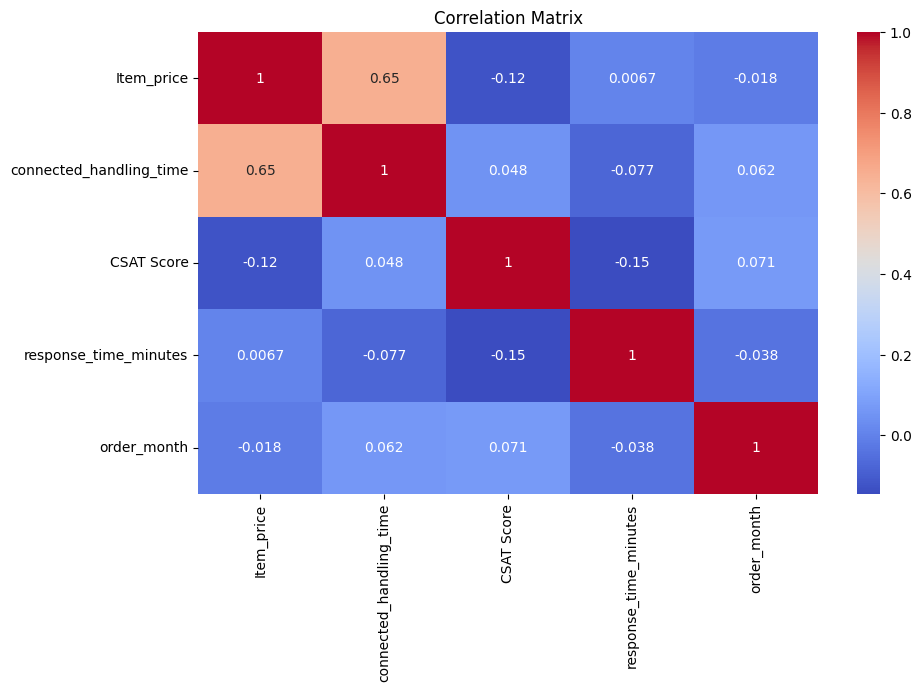

In [38]:
plt.figure(figsize = (10,6))
sns.heatmap(numeric_data.corr(), annot = True, cmap = 'coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Pair Plot Shows Relationships between Numerical features

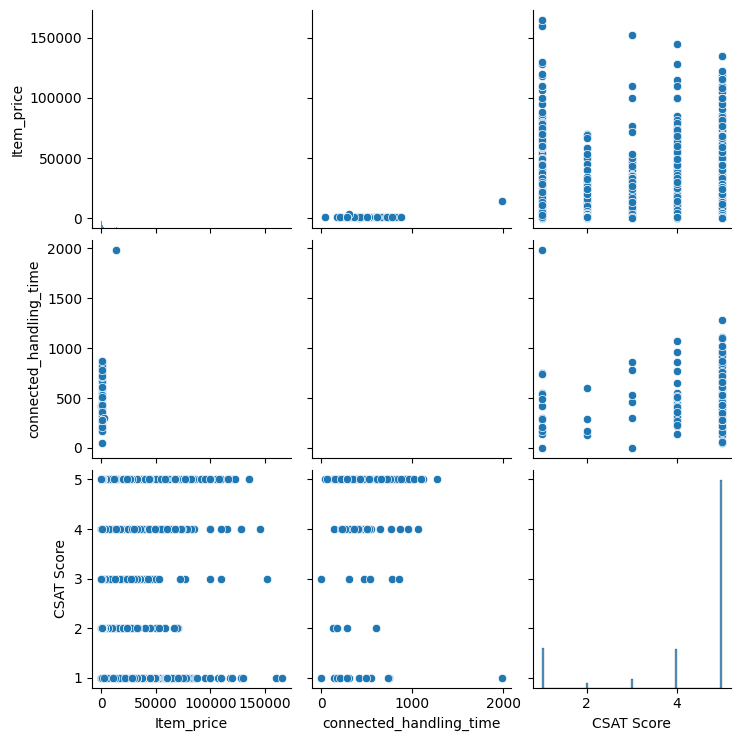

In [40]:
sns.pairplot(data[['Item_price','connected_handling_time','CSAT Score']])
plt.show()

#### Hypothesis Testing

In [166]:
from scipy import stats

In [162]:
median_time = data['connected_handling_time'].median()              # Create Two Groups
median_time 

np.float64(427.0)

In [163]:
low_time = data[data['connected_handling_time'] <= median_time]['CSAT Score']
low_time

0        5
1        5
2        5
3        5
4        5
        ..
85902    4
85903    5
85904    5
85905    4
85906    5
Name: CSAT Score, Length: 85787, dtype: int64

In [164]:
high_time = data[data['connected_handling_time'] > median_time]['CSAT Score']
high_time

9700     5
9984     5
10827    5
10905    5
11313    3
        ..
79829    5
81916    5
81971    5
83143    5
85016    4
Name: CSAT Score, Length: 120, dtype: int64

#### Perform T-Test

In [167]:
t_stat, p_value = stats.ttest_ind(low_time, high_time)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.911181845366257
P-value: 0.0036015691110496237


Answer:  Since p_value < 0.05, so Reject H0 and Handling time significantly affects CSAT and this mean CSAT for High Handling Time = Low Handling Time

H0: Mean CSAT for High Handling Time = Low Handling Time
H1: Mean CSAT is different

#### Does Channel Type Affect CSAT?

#### ANOVA Test

In [168]:
groups = [group['CSAT Score'].values for name, group in df.groupby('channel_name')]

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 98.28210579751084
P-value: 2.3194399795949356e-43


Answer:  Since p_value > 0.05, so Channel type doesn't significantly impacts CSAT also at least one channel mean is different


H0: All channel means are equal
H1: At least one channel mean is different

#### Correlation Test (Handling Time vs CSAT)

In [169]:
corr, p_value = stats.pearsonr(data['connected_handling_time'], data['CSAT Score'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.0033919240031905114
P-value: 0.32014605452853384


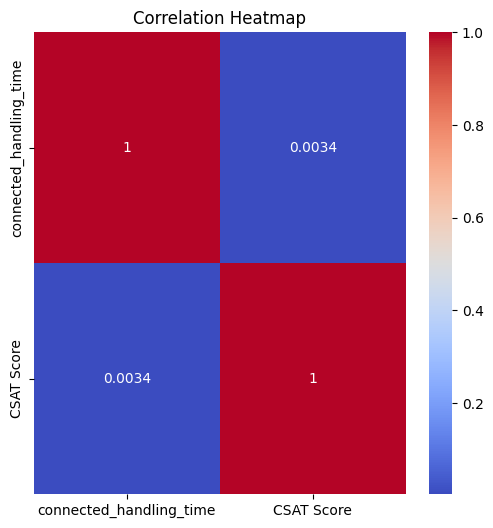

In [171]:
plt.figure(figsize=(6,6))
sns.heatmap(data[['connected_handling_time','CSAT Score']].corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Answer: Since p_value > 0.05, so no significant correlation exists

H0: No correlation
H1: Correlation exists

#### Box Plot Visualize CSAT Score 

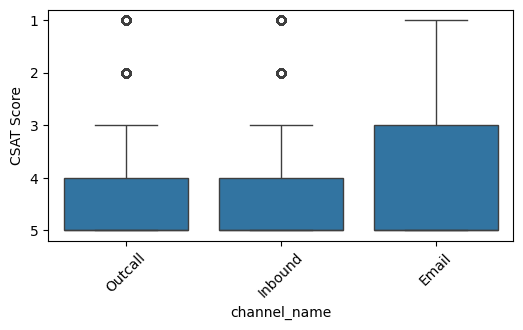

In [174]:
plt.figure(figsize = (6,3))
sns.boxplot(data = data, x ='channel_name', y ='CSAT Score')
plt.xticks(rotation = 45)
plt.gca().invert_yaxis()
plt.show()

# **Feature Engineering & Data Pre-processing**

#### Textual Data Preprocessing

In [176]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import spacy
import contractions
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [179]:
nlp = spacy.load("en_core_web_sm")
nlp

#### 1. Expand Contraction

In [196]:
def expand_contractions(text):
    return contractions.fix(text)

data['remarks_expanded'] = data['Customer Remarks'].astype(str).apply(expand_contractions)
data['remarks_expanded']

0                                             nan
1                                             nan
2                                             nan
3                                             nan
4                                             nan
                           ...                   
85902                                         nan
85903    Supported team customer executive   good
85904        need to improve with proper details.
85905                                         nan
85906                                         nan
Name: remarks_expanded, Length: 85907, dtype: object

#### 2. Lower Casing

In [197]:
data['remarks_lower'] = data['remarks_expanded'].str.lower()
data['remarks_lower']

0                                             nan
1                                             nan
2                                             nan
3                                             nan
4                                             nan
                           ...                   
85902                                         nan
85903    supported team customer executive   good
85904        need to improve with proper details.
85905                                         nan
85906                                         nan
Name: remarks_lower, Length: 85907, dtype: object

#### 3. Removing URLs

In [198]:
def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

data['remarks_no_url'] = data['remarks_lower'].apply(remove_urls)
data['remarks_no_url']

0                                             nan
1                                             nan
2                                             nan
3                                             nan
4                                             nan
                           ...                   
85902                                         nan
85903    supported team customer executive   good
85904        need to improve with proper details.
85905                                         nan
85906                                         nan
Name: remarks_no_url, Length: 85907, dtype: object

#### 4. Removing Punctuations

In [201]:
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

data['remarks_no_punct'] = data['remarks_no_url'].apply(remove_punctuation)
data['remarks_no_punct']

0                                             nan
1                                             nan
2                                             nan
3                                             nan
4                                             nan
                           ...                   
85902                                         nan
85903    supported team customer executive   good
85904         need to improve with proper details
85905                                         nan
85906                                         nan
Name: remarks_no_punct, Length: 85907, dtype: object

#### 5. Removing words and digits contain digits

In [202]:
def remove_digit_words(text):
    return re.sub(r'\w*\d\w*', '', text)

data['remarks_no_digits'] = data['remarks_no_punct'].apply(remove_digit_words)
data['remarks_no_digits']

0                                             nan
1                                             nan
2                                             nan
3                                             nan
4                                             nan
                           ...                   
85902                                         nan
85903    supported team customer executive   good
85904         need to improve with proper details
85905                                         nan
85906                                         nan
Name: remarks_no_digits, Length: 85907, dtype: object

#### 6. Removing Stopwords

In [203]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in stop_words]
    return " ".join(filtered)

data['remarks_no_stop'] = data['remarks_no_digits'].apply(remove_stopwords)
data['remarks_no_stop']

0                                           nan
1                                           nan
2                                           nan
3                                           nan
4                                           nan
                          ...                  
85902                                       nan
85903    supported team customer executive good
85904               need improve proper details
85905                                       nan
85906                                       nan
Name: remarks_no_stop, Length: 85907, dtype: object

#### 7. Removing White spaces

In [204]:
def remove_whitespace(text):
    return " ".join(text.split())

data['remarks_clean'] = data['remarks_no_stop'].apply(remove_whitespace)
data['remarks_clean']

0                                           nan
1                                           nan
2                                           nan
3                                           nan
4                                           nan
                          ...                  
85902                                       nan
85903    supported team customer executive good
85904               need improve proper details
85905                                       nan
85906                                       nan
Name: remarks_clean, Length: 85907, dtype: object

#### 8. Tokenization

In [206]:
data['tokens'] = data['remarks_clean'].apply(word_tokenize)
data['tokens']

0                                               [nan]
1                                               [nan]
2                                               [nan]
3                                               [nan]
4                                               [nan]
                             ...                     
85902                                           [nan]
85903    [supported, team, customer, executive, good]
85904                [need, improve, proper, details]
85905                                           [nan]
85906                                           [nan]
Name: tokens, Length: 85907, dtype: object

#### 9. Text Normalization

In [207]:
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

data['remarks_lemmatized'] = data['remarks_clean'].apply(lemmatize_text)
data['remarks_lemmatized']

0                                         nan
1                                         nan
2                                         nan
3                                         nan
4                                         nan
                         ...                 
85902                                     nan
85903    support team customer executive good
85904              need improve proper detail
85905                                     nan
85906                                     nan
Name: remarks_lemmatized, Length: 85907, dtype: object

#### 10. Part of speech tagging

In [208]:
def pos_tagging(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc]

data['pos_tags'] = data['remarks_clean'].apply(pos_tagging)
data['pos_tags']

0                                           [(nan, PROPN)]
1                                           [(nan, PROPN)]
2                                           [(nan, PROPN)]
3                                           [(nan, PROPN)]
4                                           [(nan, PROPN)]
                               ...                        
85902                                       [(nan, PROPN)]
85903    [(supported, VERB), (team, NOUN), (customer, N...
85904    [(need, AUX), (improve, VERB), (proper, ADJ), ...
85905                                       [(nan, PROPN)]
85906                                       [(nan, PROPN)]
Name: pos_tags, Length: 85907, dtype: object

#### 11. Rephrase Text

In [209]:
data['remarks_final'] = data['remarks_lemmatized']
data['remarks_final']

0                                         nan
1                                         nan
2                                         nan
3                                         nan
4                                         nan
                         ...                 
85902                                     nan
85903    support team customer executive good
85904              need improve proper detail
85905                                     nan
85906                                     nan
Name: remarks_final, Length: 85907, dtype: object

#### 12. Text Vectorization

In [210]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(data['remarks_final'])
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 170547 stored elements and shape (85907, 5000)>

# ***ML Model Implementation***

#### ML Model - 1

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

#### 2. Cross- Validation & Hyperparameter Tuning

#### Which hyperparameter optimization technique have you used and why?

#### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

#### Feature Engineering

In [7]:
date_cols = ['order_date_time','Issue_reported at','issue_responded','Survey_response_Date']

for col in date_cols:
    data[col] = pd.to_datetime(data[col], format = '%d-%m-%Y %H:%M', errors = 'coerce')
data[col]

0       NaT
1       NaT
2       NaT
3       NaT
4       NaT
         ..
85902   NaT
85903   NaT
85904   NaT
85905   NaT
85906   NaT
Name: Survey_response_Date, Length: 85907, dtype: datetime64[ns]

In [8]:
data['response_time_minutes'] = (data['issue_responded'] - data['Issue_reported at']).dt.total_seconds() / 60     # Create Response Time Feature
data['response_time_minutes']

0         34.0
1          2.0
2         22.0
3         20.0
4          2.0
         ...  
85902    482.0
85903      2.0
85904      5.0
85905      1.0
85906      1.0
Name: response_time_minutes, Length: 85907, dtype: float64

In [9]:
data['order_month'] = data['order_date_time'].dt.month               # Extract Order Month
data['order_month']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
85902   NaN
85903   NaN
85904   NaN
85905   NaN
85906   NaN
Name: order_month, Length: 85907, dtype: float64

In [18]:
data = data.drop(columns = [                                       # Remove Unnecessary Columns
    'Unique id','Order_id',
    'order_date_time','Issue_reported at',
    'issue_responded','Survey_response_Date',
    'Customer Remarks'])

data

,channel_name,category,Sub-category,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_minutes,order_month
0,Outcall,Product Queries,Life Insurance,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,NaN
1,Outcall,Product Queries,Product Specific Information,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,NaN
2,Inbound,Order Related,Installation/demo,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,NaN
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,NaN
4,Inbound,Cancellation,Not Needed,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4,NaN,NaN
85903,Inbound,Order Related,Seller Cancelled Order,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5,NaN,NaN
85904,Inbound,Order Related,Order status enquiry,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5,NaN,NaN
85905,Inbound,Feedback,UnProfessional Behaviour,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4,NaN,NaN


In [20]:
data = data.fillna(data.median(numeric_only = True))             # Handle Missing Values
data

,channel_name,category,Sub-category,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_minutes,order_month
0,Outcall,Product Queries,Life Insurance,NaN,NaN,979.0,427.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,8.0
1,Outcall,Product Queries,Product Specific Information,NaN,NaN,979.0,427.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,8.0
2,Inbound,Order Related,Installation/demo,NaN,NaN,979.0,427.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,8.0
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,979.0,427.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,8.0
4,Inbound,Cancellation,Not Needed,NaN,NaN,979.0,427.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,NaN,NaN,979.0,427.0,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4,6.0,8.0
85903,Inbound,Order Related,Seller Cancelled Order,NaN,NaN,979.0,427.0,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5,6.0,8.0
85904,Inbound,Order Related,Order status enquiry,NaN,NaN,979.0,427.0,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5,6.0,8.0
85905,Inbound,Feedback,UnProfessional Behaviour,NaN,NaN,979.0,427.0,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4,6.0,8.0


In [22]:
for col in data.select_dtypes(include = 'object').columns:             # Handle Missing Values
    data[col] = data[col].fillna(data[col].mode()[0])
data[col]

0        Morning
1        Morning
2        Evening
3        Evening
4        Morning
          ...   
85902    Morning
85903    Morning
85904    Evening
85905    Morning
85906    Evening
Name: Agent Shift, Length: 85907, dtype: object

In [23]:
X = data.drop('CSAT Score', axis=1)                    # Define Features & Target
y = data['CSAT Score']

#### Preprocessing (Encoding + Scaling)

#### Separate categorical & numerical columns

In [24]:
cat_cols = X.select_dtypes(include='object').columns           # Encode Categorical Features
cat_cols

Index(['channel_name', 'category', 'Sub-category', 'Customer_City',
       'Product_category', 'Agent_name', 'Supervisor', 'Manager',
       'Tenure Bucket', 'Agent Shift'],
      dtype='object')

In [25]:
num_cols = X.select_dtypes(include=np.number).columns
num_cols

Index(['Item_price', 'connected_handling_time', 'response_time_minutes',
       'order_month'],
      dtype='object')

In [26]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])  # Preprocessing Pipeline    
preprocessor                                           # Preprocessing Pipeline

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


#### LINEAR REGRESSION (Predict Exact CSAT)

In [27]:
linreg_pipeline = Pipeline([('preprocessor', preprocessor),('model', LinearRegression())])     # Create Pipeline
linreg_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)   # Splitting Dataset
X_train, X_test, y_train, y_test

(      channel_name          category                  Sub-category  \
 5056       Inbound     Order Related                       Delayed   
 43070      Inbound           Returns        Reverse Pickup Enquiry   
 70807      Outcall  Payments related               Billing Related   
 24015      Inbound           Returns        Reverse Pickup Enquiry   
 20160      Inbound     Order Related                       Delayed   
 ...            ...               ...                           ...   
 6265       Inbound     Order Related                       Delayed   
 54886      Inbound   Product Queries  Product Specific Information   
 76820      Inbound     Order Related          Order status enquiry   
 860        Outcall           Returns        Reverse Pickup Enquiry   
 15795      Inbound           Returns                         Wrong   
 
       Customer_City             Product_category  Item_price  \
 5056        BEERWAH  Books & General merchandise      1690.0   
 43070     HYDER

In [29]:
linreg_pipeline.fit(X_train, y_train)                # Train Model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
y_pred = linreg_pipeline.predict(X_test)                                # Evaluate model

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.03912038122764294
RMSE: 1.3473395989546293


In [31]:
cv_scores = cross_val_score(linreg_pipeline, X, y, cv = 5, scoring='r2')         # Cross-Validation

print("CV R2 Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

CV R2 Scores: [ 0.04095964  0.03486939  0.0354858   0.02508919 -0.00799167]
Average CV Score: 0.02568246798848812


#### Tune Linear Regression (Ridge/Lasso)

In [32]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([('preprocessor', preprocessor),('model', Ridge())])

param_grid = {'model__alpha': [0.01, 0.1, 1, 10]}

grid = GridSearchCV(ridge_pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)

Best Alpha: {'model__alpha': 10}


#### LOGISTIC REGRESSION (High vs Low CSAT)

In [34]:
data['CSAT_binary'] = np.where(data['CSAT Score'] >= 4, 1, 0)                # Convert CSAT to binary:
data['CSAT_binary']    

0        1
1        1
2        1
3        1
4        1
        ..
85902    1
85903    1
85904    1
85905    1
85906    1
Name: CSAT_binary, Length: 85907, dtype: int64

In [35]:
X = data.drop(['CSAT Score','CSAT_binary'], axis=1)
y = data['CSAT_binary']

In [36]:
logreg_pipeline = Pipeline([('preprocessor', preprocessor),('model', LogisticRegression(max_iter=1000))])   # Create Pipeline
logreg_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
logreg_pipeline.fit(X_train, y_train)                  # Train model

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
y_pred = logreg_pipeline.predict(X_test)                            # Evaluate model

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6936328716098242
              precision    recall  f1-score   support

           1       0.42      0.08      0.14      2241
           2       0.00      0.00      0.00       227
           3       0.00      0.00      0.00       503
           4       0.15      0.00      0.00      2277
           5       0.70      0.98      0.82     11934

    accuracy                           0.69     17182
   macro avg       0.25      0.21      0.19     17182
weighted avg       0.56      0.69      0.59     17182



C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [41]:
cv_scores = cross_val_score(logreg_pipeline, X, y, cv=5, scoring='accuracy')        # Cross-Validation

print("CV Accuracy:", cv_scores.mean())

CV Accuracy: 0.8246126787832664


#### HYPERPARAMETER TUNING (GridSearchCV)

In [42]:
param_grid = {'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}
param_grid

{'model__C': [0.01, 0.1, 1, 10],
 'model__penalty': ['l2'],
 'model__solver': ['lbfgs']}

In [43]:
grid_search = GridSearchCV(logreg_pipeline, param_grid, cv = 5, scoring='accuracy', n_jobs = -1)   # Apply GridSearch

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [44]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Score: 0.6955983994179702


I implemented Linear and Logistic Regression models with proper preprocessing pipelines. I applied 5-fold cross-validation to evaluate generalization performance and used GridSearchCV to tune hyperparameters like regularization strength, achieving improved accuracy

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
pip install tensorflow

     ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
     ---------------------------------------- 0.5/331.7 MB 9.6 MB/s eta 0:00:35
     --------------------------------------- 1.0/331.7 MB 12.3 MB/s eta 0:00:27
     --------------------------------------- 1.5/331.7 MB 11.8 MB/s eta 0:00:28
     --------------------------------------- 2.0/331.7 MB 10.9 MB/s eta 0:00:31
     --------------------------------------- 2.6/331.7 MB 11.6 MB/s eta 0:00:29
     --------------------------------------- 3.0/331.7 MB 11.4 MB/s eta 0:00:29
     --------------------------------------- 3.6/331.7 MB 11.5 MB/s eta 0:00:29
     --------------------------------------- 4.0/331.7 MB 10.8 MB/s eta 0:00:31
      -------------------------------------- 4.5/331.7 MB 11.0 MB/s eta 0:00:30
      -------------------------------------- 5.0/331.7 MB 11.1 MB/s eta 0:00:30
      -------------------------------------- 5.5/331.7 MB 11.0 MB/s eta 0:00:30
      -------------------------------------- 6.


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
data = data.drop(columns = ['Unique id','Order_id','Customer Remarks'])     # Remove Unnecessary Columns
data

,channel_name,category,Sub-category,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,Outcall,Product Queries,Life Insurance,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,Outcall,Product Queries,Product Specific Information,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,Inbound,Order Related,Installation/demo,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,Inbound,Cancellation,Not Needed,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,NaN,30-08-2023 23:20,31-08-2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,Inbound,Order Related,Seller Cancelled Order,NaN,31-08-2023 08:15,31-08-2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,Inbound,Order Related,Order status enquiry,NaN,31-08-2023 18:57,31-08-2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,Inbound,Feedback,UnProfessional Behaviour,NaN,31-08-2023 19:59,31-08-2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4


#### Feature Engineering

In [138]:
data = data.drop(columns = date_cols)
data

,channel_name,category,Sub-category,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_minutes,order_month
0,Outcall,Product Queries,Life Insurance,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,NaN
1,Outcall,Product Queries,Product Specific Information,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,NaN
2,Inbound,Order Related,Installation/demo,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,NaN
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,NaN
4,Inbound,Cancellation,Not Needed,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4,NaN,NaN
85903,Inbound,Order Related,Seller Cancelled Order,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5,NaN,NaN
85904,Inbound,Order Related,Order status enquiry,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5,NaN,NaN
85905,Inbound,Feedback,UnProfessional Behaviour,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4,NaN,NaN


In [139]:
data = data.fillna(data.median(numeric_only = True))                   # Handle Missing Values
data

,channel_name,category,Sub-category,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_minutes,order_month
0,Outcall,Product Queries,Life Insurance,NaN,NaN,979.0,427.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,8.0
1,Outcall,Product Queries,Product Specific Information,NaN,NaN,979.0,427.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,8.0
2,Inbound,Order Related,Installation/demo,NaN,NaN,979.0,427.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,8.0
3,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,979.0,427.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,8.0
4,Inbound,Cancellation,Not Needed,NaN,NaN,979.0,427.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85902,Inbound,Refund Related,Refund Enquiry,NaN,NaN,979.0,427.0,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4,6.0,8.0
85903,Inbound,Order Related,Seller Cancelled Order,NaN,NaN,979.0,427.0,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5,6.0,8.0
85904,Inbound,Order Related,Order status enquiry,NaN,NaN,979.0,427.0,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5,6.0,8.0
85905,Inbound,Feedback,UnProfessional Behaviour,NaN,NaN,979.0,427.0,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4,6.0,8.0


In [141]:
X = data.drop('CSAT Score', axis = 1)                          # Define Features & Target
y = data['CSAT Score']

In [142]:
le = LabelEncoder()
y = le.fit_transform(y)

#### Create preprocessing pipeline

In [145]:
preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [148]:
X = preprocessor.fit_transform(X)                           # Apply Preprocessing
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1202698 stored elements and shape (85907, 3294)>

In [151]:
X = X.astype('float32')
X

array([[-0.15530242, -0.00756666, -0.15824136, ...,  1.        ,
         0.        ,  0.        ],
       [-0.15530242, -0.00756666, -0.16125372, ...,  1.        ,
         0.        ,  0.        ],
       [-0.15530242, -0.00756666, -0.15937099, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.15530242, -0.00756666, -0.16087717, ...,  0.        ,
         0.        ,  0.        ],
       [-0.15530242, -0.00756666, -0.16087717, ...,  1.        ,
         0.        ,  0.        ],
       [-0.15530242, -0.00756666, -0.16087717, ...,  0.        ,
         0.        ,  0.        ]], shape=(85907, 3294), dtype=float32)

In [152]:
y = y.astype('int32')
y

array([4, 4, 4, ..., 4, 3, 4], shape=(85907,), dtype=int32)

In [153]:
print(X.dtype)

float32


In [154]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)     # Train-Test Split
X_train, X_test, y_train, y_test

(array([[-3.7545636e-02, -7.5666578e-03, -1.6106544e-01, ...,
          1.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-1.5530242e-01, -7.5666578e-03, -1.6087717e-01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-1.5530242e-01, -7.5666578e-03, -1.6087717e-01, ...,
          1.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        ...,
        [-1.5530242e-01, -7.5666578e-03, -1.6087717e-01, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-1.5530242e-01, -7.5666578e-03, -1.6134785e-01, ...,
          1.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [-8.9881986e-02, -7.5666578e-03,  8.0828199e+00, ...,
          1.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
       shape=(68725, 3294), dtype=float32),
 array([[-0.15530242, -0.00756666, -0.16087717, ...,  1.        ,
          0.        ,  0.        ],
        [-0.29160878, -0.00756666, -0.16087717, ...,  0.        ,
          0.        ,  0.        ],
        [-0.155302

#### Build ANN Model

In [156]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(32, activation='relu'),
    
    layers.Dense(len(np.unique(y)), activation='softmax')                            # For multi-class
])

In [157]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])   # Complie model


In [158]:
history = model.fit(X_train, y_train, epochs = 30, batch_size = 32)       # Train Model
history

Epoch 1/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.6925 - loss: 0.9498
Epoch 2/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6953 - loss: 0.9174
Epoch 3/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6976 - loss: 0.9046
Epoch 4/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.7005 - loss: 0.8894
Epoch 5/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.7052 - loss: 0.8715
Epoch 6/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7095 - loss: 0.8533
Epoch 7/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7141 - loss: 0.8332
Epoch 8/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.7196 - loss: 0.8118
Epoch 9/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7272 - loss: 0.7928
Epoch 10/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7306 - loss: 0.7719
Epoch 11/30
2148/2148 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.7363 - loss: 0.7555
Epoch 12/30
2148

#### Evaluate Model

In [159]:
loss, accuracy = model.evaluate(X_test, y_test)                      
print("Test Accuracy:", accuracy)

537/537 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6637 - loss: 1.3873
Test Accuracy: 0.6637178659439087


#### Predictions

In [160]:
y_pred = model.predict(X_test)                                    
y_pred

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[6.9769554e-02, 1.0230608e-02, 2.2036115e-02, 7.0341110e-02,
        8.2762259e-01],
       [4.6082554e-04, 4.4412314e-04, 5.1357769e-03, 2.1612085e-01,
        7.7783835e-01],
       [9.9490024e-02, 1.0850549e-03, 5.1323669e-03, 5.3747877e-02,
        8.4054464e-01],
       ...,
       [1.1906103e-01, 6.6942405e-03, 1.3776226e-02, 2.8426769e-01,
        5.7620078e-01],
       [3.4728843e-01, 1.1792660e-01, 2.3557714e-01, 9.1321312e-02,
        2.0788659e-01],
       [2.0466134e-01, 4.0602427e-02, 7.0377111e-02, 1.0702501e-01,
        5.7733417e-01]], shape=(17182, 5), dtype=float32)

In [161]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes

array([4, 4, 4, ..., 4, 0, 4], shape=(17182,))